In [39]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings

In [40]:
warnings.filterwarnings('ignore')

# Data Collection


In [41]:
df = pd.read_csv("../data/CarData.csv")

# EDA 

In [42]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [43]:
print(df.shape)    # which means there are 8128 rows and 13 columns 
print(df.columns)  # returns columns names

(8128, 13)
Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')


In [44]:
print(df.info())   # now we know that we are having some of the columns with null value and few value columns as object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB
None


In [45]:
print(df.describe())

              year  selling_price     km_driven        seats
count  8128.000000   8.128000e+03  8.128000e+03  7907.000000
mean   2013.804011   6.382718e+05  6.981951e+04     5.416719
std       4.044249   8.062534e+05  5.655055e+04     0.959588
min    1983.000000   2.999900e+04  1.000000e+00     2.000000
25%    2011.000000   2.549990e+05  3.500000e+04     5.000000
50%    2015.000000   4.500000e+05  6.000000e+04     5.000000
75%    2017.000000   6.750000e+05  9.800000e+04     5.000000
max    2020.000000   1.000000e+07  2.360457e+06    14.000000


In [46]:
print(df.isnull().sum())   # we check the total number of null values in each columns

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64


In [47]:
# ectracting the numeric value from the object and converting them into float 
objectCol = ["mileage", "engine", "max_power"]

for col in objectCol:
    df[col] = df[col].str.extract(r"(\d+\.?\d*)").astype(float)

df[objectCol].head()

,mileage,engine,max_power
0,23.40,1248.0,74.00
1,21.14,1498.0,103.52
2,17.70,1497.0,78.00
3,23.00,1396.0,90.00
4,16.10,1298.0,88.20


In [48]:
# torque column is also have the numeric value, but the important part is that we shouldn't just extract the first number blindly.
# From the torque values we have things like: 190Nm@ 2000rpm → 190 Nm, 250Nm@ 1500-2500rpm → 250 Nm etc
# so, convert every torque value into one consistent numeric unit: Nm
import re

def parse_torque(value):
    if pd.isna(value):
        return np.nan

    s = str(value).strip().lower()

    match = re.search(r"(\d+(?:\.\d+)?)", s)

    if not match:
        return np.nan

    torque = float(match.group(1))

    # kgm→ Nm
    if "kgm" in s or "kg-m" in s:
        torque = torque * 9.80665

    return torque


df["torque_nm"] = df["torque"].apply(parse_torque)  # created a new column for torque flaot values 

# Visualization- to see distribution of numeric cols, categorical cols and correlation b/w target variables

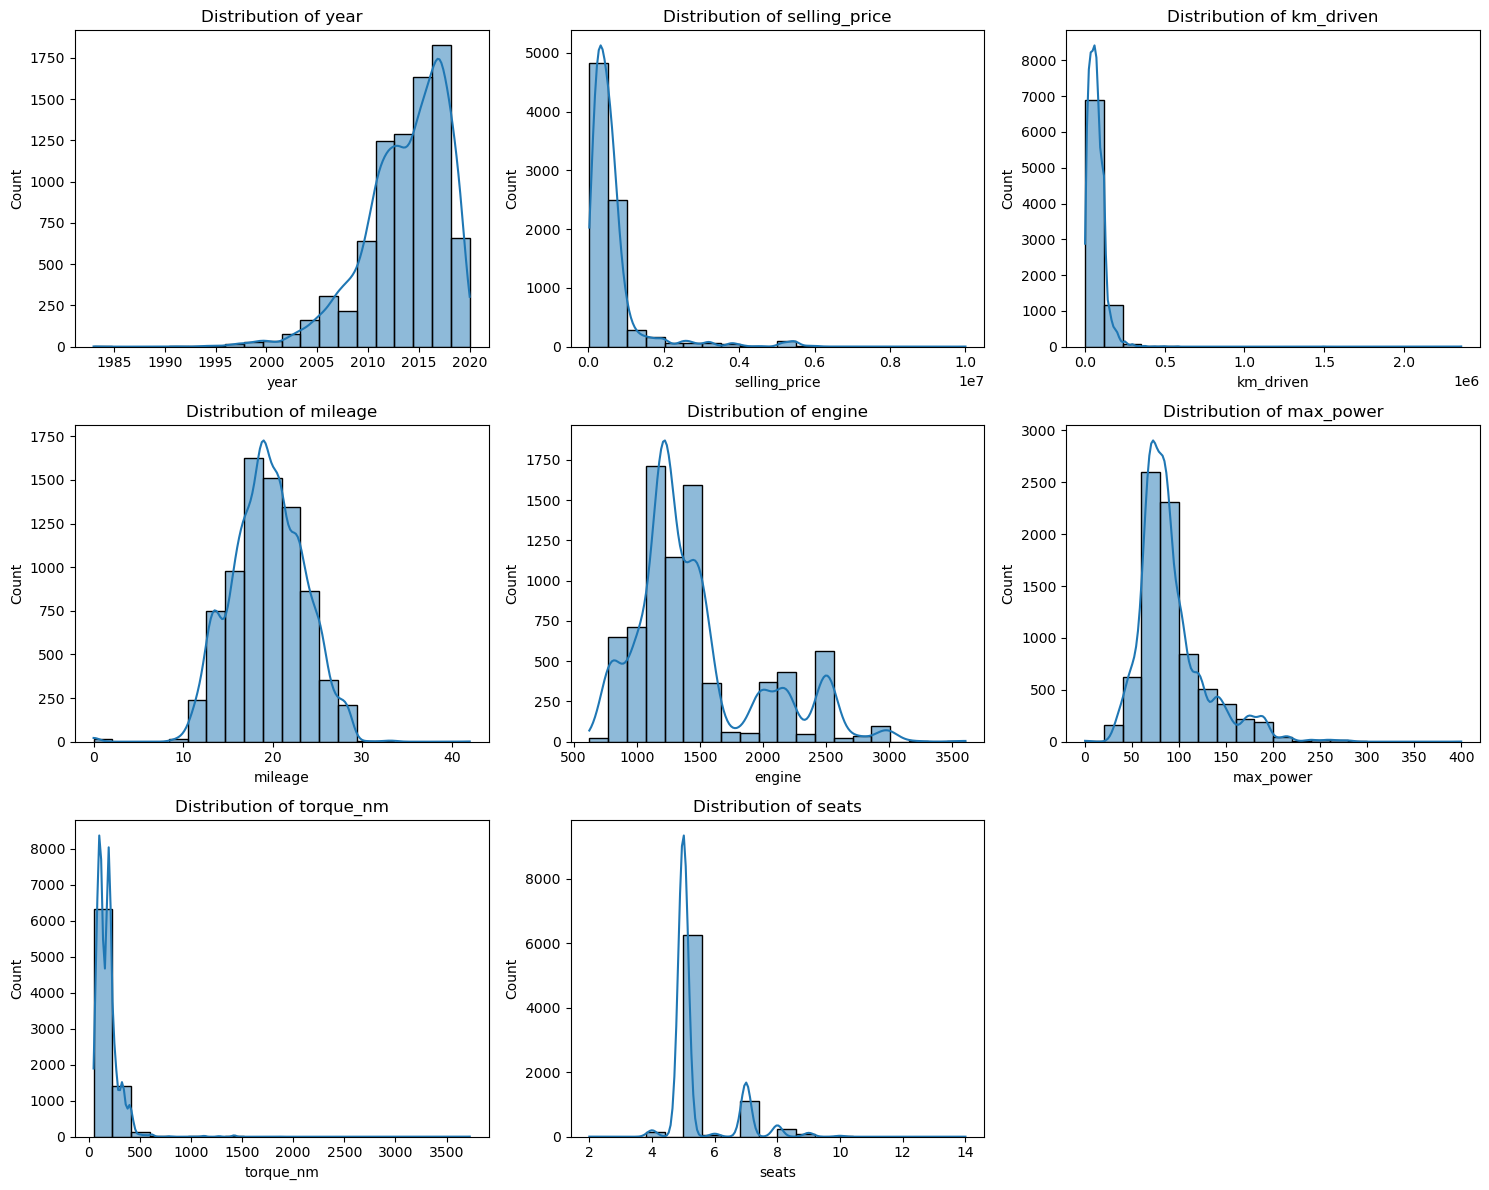

In [49]:
numeric_columns = ['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'torque_nm', 'seats']

plt.figure(figsize=(15, 12))

for idx, col in enumerate(numeric_columns):
    plt.subplot(3, 3, idx + 1)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

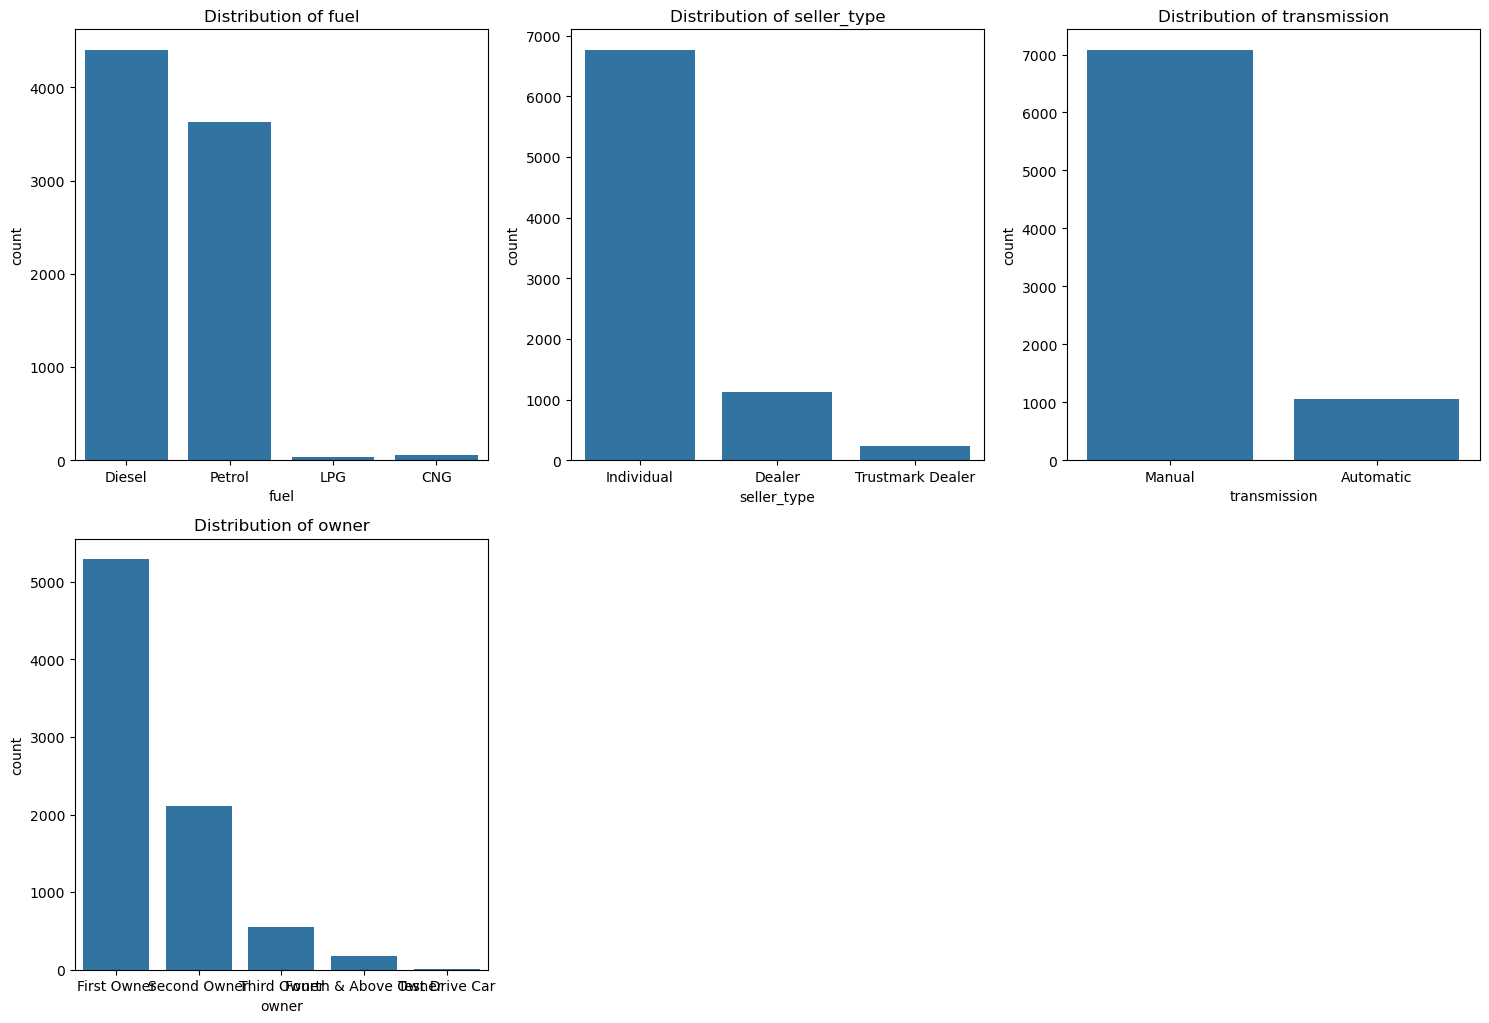

In [50]:
categorical_columns = ['fuel', 'seller_type', 'transmission', 'owner']

plt.figure(figsize=(15,15))

for idx,cat in enumerate(categorical_columns):
    plt.subplot(3, 3, idx + 1)
    sns.countplot(x = df[cat]) 
    plt.title(f'Distribution of {cat}')

plt.tight_layout()
plt.show()

<Axes: >

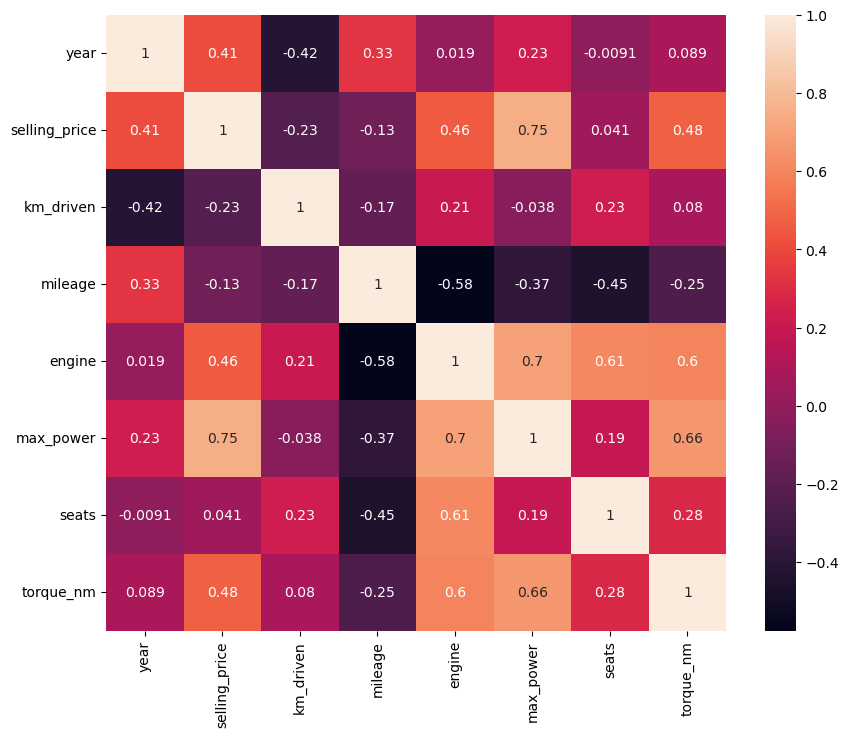

In [51]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only = True), annot = True)

# Data Cleaning and Preprocessing

In [52]:
df_cleaned = df.copy()   #created copy of the dataSet, so the original dataset remain untouched

In [53]:
# filled out the numeric missing values with its, mean
missing_value = ['mileage', 'engine', 'max_power', 'torque_nm', 'seats']

for miss in missing_value: 
    df_cleaned[missing_value] = df_cleaned[missing_value].fillna(df_cleaned[missing_value].mean())

In [54]:
print(df_cleaned.isnull().sum())
# so now there is no missing value except "torque" because we converted the torque in same unit in "torque_nm" column

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage            0
engine             0
max_power          0
torque           222
seats              0
torque_nm          0
dtype: int64


In [55]:
df_cleaned["brand"] = df_cleaned["name"].str.split().str[0] # create a brand column from name

In [56]:
duplicate_rows = df_cleaned.duplicated().sum()
duplicate_rows  #so there are 1202 rows with exact same values, that means we can drop these

1202

In [57]:
df_cleaned.drop_duplicates(inplace=True) 
df_cleaned.shape  #initially we have 8128 rows but now we remain with 6926 rows only due to duplication of values

(6926, 15)

In [58]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6926 entries, 0 to 8125
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6926 non-null   object 
 1   year           6926 non-null   int64  
 2   selling_price  6926 non-null   int64  
 3   km_driven      6926 non-null   int64  
 4   fuel           6926 non-null   object 
 5   seller_type    6926 non-null   object 
 6   transmission   6926 non-null   object 
 7   owner          6926 non-null   object 
 8   mileage        6926 non-null   float64
 9   engine         6926 non-null   float64
 10  max_power      6926 non-null   float64
 11  torque         6717 non-null   object 
 12  seats          6926 non-null   float64
 13  torque_nm      6926 non-null   float64
 14  brand          6926 non-null   object 
dtypes: float64(5), int64(3), object(7)
memory usage: 865.8+ KB


In [59]:
df_cleaned["transmission"].value_counts()

transmission
Manual       6342
Automatic     584
Name: count, dtype: int64

In [60]:
# Encoding the categorical data 
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder() 
df_cleaned['transmission'] = le.fit_transform(df_cleaned['transmission'])

encoding_cols = ['fuel', 'seller_type', 'owner', 'brand']
df_cleaned = pd.get_dummies(df_cleaned, columns=encoding_cols, drop_first=True)

In [61]:
# after encoding, now convert the true false thing into 0 and 1 

new_numerical_column = ['fuel_Diesel','fuel_LPG','fuel_Petrol','seller_type_Individual','seller_type_Trustmark Dealer','owner_Fourth & Above Owner',
                        'owner_Second Owner','owner_Test Drive Car','owner_Third Owner','brand_Ashok','brand_Audi','brand_BMW','brand_Chevrolet',
                        'brand_Daewoo','brand_Datsun','brand_Fiat','brand_Force','brand_Ford','brand_Honda','brand_Hyundai','brand_Isuzu',
                        'brand_Jaguar','brand_Jeep','brand_Kia','brand_Land','brand_Lexus','brand_MG','brand_Mahindra','brand_Maruti',
                        'brand_Mercedes-Benz','brand_Mitsubishi','brand_Nissan','brand_Opel','brand_Peugeot','brand_Renault','brand_Skoda',
                        'brand_Tata','brand_Toyota','brand_Volkswagen','brand_Volvo'
                        ]

for data in new_numerical_column: 
    df_cleaned[data] = df_cleaned[data].astype(int)

# Feature Selection & Engineering

In [62]:
from sklearn.preprocessing import StandardScaler

numeric_scaling_cols = ['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'torque_nm'] 

ss = StandardScaler() 
df_cleaned[numeric_scaling_cols] = ss.fit_transform(df_cleaned[numeric_scaling_cols])

In [63]:
# now checking the correlation, of all the features with selling-price
from scipy.stats import pearsonr

selected_features = ['year', 'km_driven', 'transmission', 'mileage',
       'engine', 'max_power', 'seats', 'torque_nm', 'fuel_Diesel',
       'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual',
       'seller_type_Trustmark Dealer', 'owner_Fourth & Above Owner',
       'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner',
       'brand_Ashok', 'brand_Audi', 'brand_BMW', 'brand_Chevrolet',
       'brand_Daewoo', 'brand_Datsun', 'brand_Fiat', 'brand_Force',
       'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Isuzu',
       'brand_Jaguar', 'brand_Jeep', 'brand_Kia', 'brand_Land', 'brand_Lexus',
       'brand_MG', 'brand_Mahindra', 'brand_Maruti', 'brand_Mercedes-Benz',
       'brand_Mitsubishi', 'brand_Nissan', 'brand_Opel', 'brand_Peugeot',
       'brand_Renault', 'brand_Skoda', 'brand_Tata', 'brand_Toyota',
       'brand_Volkswagen', 'brand_Volvo']

target = 'selling_price'

correlations = {}

for feature in selected_features: 
    if feature == target: 
        continue

    r, p = pearsonr(df_cleaned[feature].dropna(), df_cleaned.loc[df_cleaned[feature].notna(), target])
    
    correlations[feature] = {
        'correlation': r,
        'p_value': p
    }

    correlation_df = pd.DataFrame(correlations).T
    correlation_df = correlation_df.sort_values(by='correlation', ascending=False)

correlated_features = correlation_df[correlation_df['correlation'].abs() >= 0.2].index.tolist()
correlated_features

['max_power',
 'torque_nm',
 'engine',
 'year',
 'brand_BMW',
 'brand_Mercedes-Benz',
 'fuel_Diesel',
 'brand_Audi',
 'brand_Volvo',
 'owner_Test Drive Car',
 'fuel_Petrol',
 'seller_type_Individual',
 'transmission']

In [64]:
final_features = correlated_features + ['selling_price']
final_df = df_cleaned[final_features].copy()

final_df.head()

,max_power,torque_nm,engine,year,brand_BMW,brand_Mercedes-Benz,fuel_Diesel,brand_Audi,brand_Volvo,owner_Test Drive Car,fuel_Petrol,seller_type_Individual,transmission,selling_price
0,-0.442164,0.128944,-0.378023,0.142153,0,0,1,0,0,0,0,1,1,-0.129434
1,0.500971,0.657371,0.136366,0.142153,0,0,1,0,0,0,0,1,1,-0.283360
2,-0.314368,-0.447531,0.134309,-1.819597,0,0,0,0,0,0,1,1,1,-0.691265
3,0.069020,0.390242,-0.073505,-0.838722,0,0,1,0,0,0,0,1,1,-0.562352
4,0.011512,-0.551173,-0.275145,-1.574378,0,0,0,0,0,0,1,1,1,-0.745139


# Split the Dataset

In [65]:
from sklearn.model_selection import train_test_split

X = final_df.drop('selling_price', axis=1)
y = final_df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [66]:
# Model Selection (LinearRegression,Ridge,Lasso,RandomForest,GradientBoosting,XGBoost,LightGBM)
from sklearn.linear_model import LinearRegression, Lasso, Ridge  
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor 
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score

In [67]:
models = {
    "LinearRegression": LinearRegression(), 
    "Lasso": Lasso(), 
    "Ridge": Ridge(), 
    "RF": RandomForestRegressor(random_state=42), 
    "GB": GradientBoostingRegressor(random_state=42), 
    "XGBoost": XGBRegressor(random_state=42),
}

In [68]:
result = [] 

for name, model in models.items(): 
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse =  mean_squared_error(y_test, y_pred) 
    rmse = np.sqrt(mse)
    
    cv_r2 = cross_val_score(model, X, y, cv=5, scoring="r2") #5fold
    
    result.append({
        'Model': name,
        "r2": round(r2,4) ,
        "mae" : round(mae,4), 
        "mse": round(mse,4),
        "rmse" : round(rmse,4), 
        "cv_r2_mean": round(cv_r2.mean(), 4),
        "cv_r2_std": round(cv_r2.std(), 4)
    }) 

result_df = pd.DataFrame(result)

result_df.sort_values(by="cv_r2_mean",ascending=False)
result_df

,Model,r2,mae,mse,rmse,cv_r2_mean,cv_r2_std
0,LinearRegression,0.6576,0.2916,0.2780,0.5273,0.6675,0.0345
1,Lasso,-0.0020,0.5297,0.8136,0.9020,-0.0013,0.0011
2,Ridge,0.6622,0.2930,0.2743,0.5237,0.6671,0.0369
3,RF,0.9277,0.1402,0.0587,0.2423,0.8816,0.0282
4,GB,0.9103,0.1657,0.0729,0.2699,0.8812,0.0249
5,XGBoost,0.9252,0.1380,0.0607,0.2464,0.8753,0.0441


In [69]:
#after hyperr parameter tuning 
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, ParameterGrid

In [70]:
parameter_dict = {
    "Lasso": {
        "alpha": [0.001,0.01,0.1,1,10],
        "max_iter":[5000,10000]
    }, 
    "Ridge": {
        "alpha": [0.01,0.1,1,10,100],
    }, 
    "RF": {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    "GB": {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [2, 3, 5],
        "subsample": [0.8, 1.0]
    }, 
    "XGBoost": {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [3, 4, 5, 6, 8],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
    }       
}

In [71]:
tuned_models = {} 
tuned_results = [] 

for name, params in parameter_dict.items(): 
    print(f"Tuning : {name}")

    model = models[name]
    
    # Avoid requesting more combinations than exist
    n_iter = min(15, len(list(ParameterGrid(params))))

    search = RandomizedSearchCV(estimator=model, param_distributions=params,
                               cv=5, n_iter=n_iter, scoring="r2")

    search.fit(X_train, y_train)
    tuned_models[name] = search.best_estimator_
    
    tuned_results.append({
        'Model': name,
        "Best_CV_R2": round(search.best_score_, 4),
        "Best_Params": search.best_params_
    })

tuning_results_df = pd.DataFrame(tuned_results)

tuning_results_df.sort_values(
    by="Best_CV_R2",
    ascending=False
)

Tuning : Lasso
Tuning : Ridge
Tuning : RF
Tuning : GB
Tuning : XGBoost


,Model,Best_CV_R2,Best_Params
3,GB,0.9049,"{'subsample': 1.0, 'n_estimators': 200, 'max_d..."
4,XGBoost,0.8991,"{'subsample': 0.7, 'n_estimators': 300, 'max_d..."
2,RF,0.8928,"{'n_estimators': 200, 'min_samples_split': 2, ..."
1,Ridge,0.6861,{'alpha': 0.1}
0,Lasso,0.6783,"{'max_iter': 5000, 'alpha': 0.001}"


In [72]:
best_name = max(
    tuned_results,
    key=lambda item: item["Best_CV_R2"]
)["Model"]

best_model = tuned_models[best_name]

y_pred = best_model.predict(X_test)

print("Selected model:", best_name)
print("Test R²:", r2_score(y_test, y_pred))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Selected model: GB
Test R²: 0.9338127231127279
Test MAE: 0.1440546538747586
Test RMSE: 0.2318198662693257


In [73]:
best_model = tuned_models["GB"]

y_pred = best_model.predict(X_test)

print("Test R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Test R²: 0.9338127231127279
MAE: 0.1440546538747586
MSE: 0.05374045039712805
RMSE: 0.2318198662693257


In [74]:
# converting GB model into pickle file and saving it in the pickle file 
import joblib 
import os 

os.makedirs("../models/", exist_ok=True) 

joblib.dump(best_model, "../models/best_car_price_model.pkl") 
print("Model Saved in Pickle File.")

Model Saved in Pickle File.


In [75]:
# testing .pkl file 
import joblib
import numpy as np

loaded_model = joblib.load("../models/best_car_price_model.pkl")

sample = X_test.iloc[[0]]
prediction = loaded_model.predict(sample)

print("Predicted price:", prediction[0])
print("Actual price:", y_test.iloc[0])

Predicted price: -0.010017353588914446
Actual price: 0.06297376606666989


,Feature,Importance
0,max_power,0.587609
3,year,0.257627
1,torque_nm,0.095305
2,engine,0.024336
12,transmission,0.013530
5,brand_Mercedes-Benz,0.006621
6,fuel_Diesel,0.004134
4,brand_BMW,0.003252
9,owner_Test Drive Car,0.002466
11,seller_type_Individual,0.002076


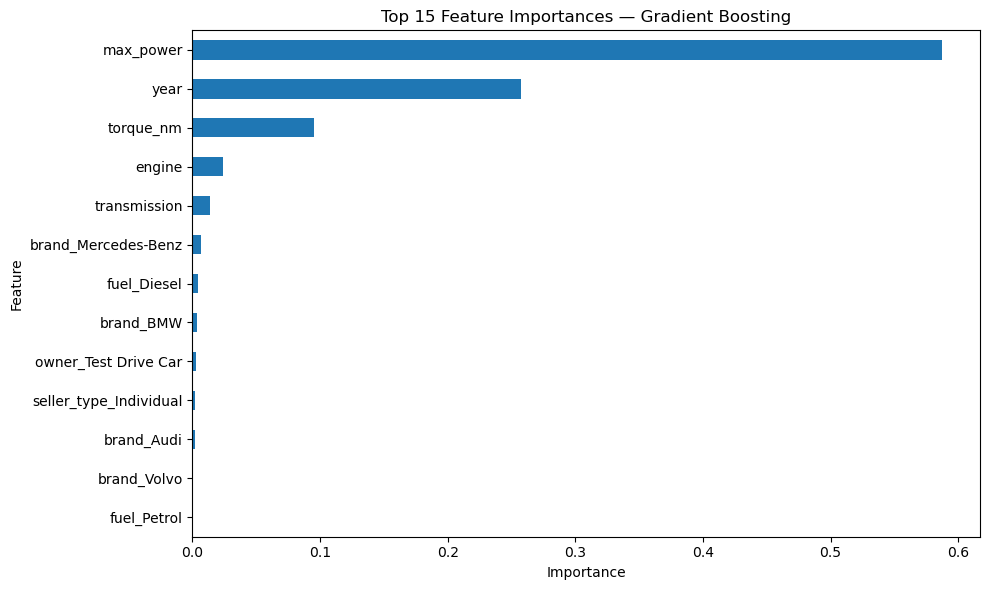

In [76]:
# which features influence your car-price predictions most

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

display(feature_importance.head(15))

feature_importance.head(15).sort_values(
    by="Importance").plot(x="Feature", y="Importance", kind="barh", legend=False, figsize=(10, 6))

plt.title("Top 15 Feature Importances — Gradient Boosting")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()